# Linear Regression - Top model according to the SCPM of -6.59

In [1]:
%load_ext nb_black

<IPython.core.display.Javascript object>

In [2]:
# Database Reading and Manipulation
import pandas as pd

# Linear Algebra
import numpy as np

# Plotting
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Model Selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GridSearchCV

# Modeling
from sklearn.linear_model import LinearRegression

# Metrics
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import r2_score

# Processing
from sklearn.preprocessing import StandardScaler

# Pipeline
from sklearn.pipeline import Pipeline

# Data imputation
from sklearn.impute import SimpleImputer

# Custom modules
## Model selection
from src.cross_validation.blocking_time_series_split import BlockingTimeSeriesSplit

## Function to print scores
from src.utils.print_scores import print_scores

## Function to calculate score regression metrics
from src.utils.score_regression_metrics import score_regression_metrics

## Function to fill the results metric dict
from src.utils.fill_results_dict import fill_results_dict

# Warnings
import warnings

<IPython.core.display.Javascript object>

# Functions and definitions

In [3]:
def get_linreg_df_importances(scores):
    coefs = {}
    bias = {}
    coefs_with_column = []
    columns = x.columns

    for index, pipeline in enumerate(scores["estimator"]):
        model = pipeline.named_steps["estimator"]
        coefs[index] = model.coef_.copy()
        bias[index] = model.intercept_.copy()

    for index, coefs_vec in coefs.items():
        coefs_col = pd.DataFrame(
            {col: [c] for col, c in zip(columns, coefs_vec)},
            index=[f"Coefficients - {index}"],
        )
        coefs_with_column.append(coefs_col)
    df_bias = pd.Series(bias)
    df_coefs = pd.concat(coefs_with_column)

    return df_coefs, df_bias

<IPython.core.display.Javascript object>

In [4]:
SEED = 47
METRICS = (
    "neg_root_mean_squared_error",
    "neg_mean_absolute_error",
    "neg_mean_absolute_percentage_error",
    "r2",
)
METRICS_DICT = {
    "neg_root_mean_squared_error": "RMSE",
    "neg_mean_absolute_error": "MAE",
    "neg_mean_absolute_percentage_error": "MAPE",
    "r2": "R2",
}

<IPython.core.display.Javascript object>

## Defining a dataframe structure to save the results

In [5]:
results_to_save = []

results_dict = {
    "Category": "Local Model",
    "Company": "partner_ii",
    "Features": "Chemical + Mineralogical + Physical",
    "Data Shape": None,
    "Timesteps": None,
    "Model": "Linear Regression",
    "Model Params": None,
    "Scaler": "Standard Scaler",
    "Scaler Params": None,
    "Imputer": "Median",
    "Imputer Params": None,
    "Cross Validation": None,
    "Cross Validation Params": np.nan,
    "RMSE Train": np.nan,
    "MAE Train": np.nan,
    "MAPE Train": np.nan,
    "R2 Train": np.nan,
    "RMSE Test": np.nan,
    "MAE Test": np.nan,
    "MAPE Test": np.nan,
    "R2 Test": np.nan,
}

<IPython.core.display.Javascript object>

# Reading the dataset

In [6]:
df = pd.read_csv("../../../../data/processed/partner_ii//cement-shipping.csv")

<IPython.core.display.Javascript object>

## Defining Features

In this set of experiments we keep only chemical and mineralogical features yielded by the same testing method/procedure

In [7]:
df_copy = df.copy().drop(
    [
        "Cement_Type",
    ],
    axis=1,
)

<IPython.core.display.Javascript object>

# 1. Linear Regression

<h2>1. Dataset: df_no_cs</h2> <br>In this dataset the CS1, CS3  and CS7 variables are not considered. Only Chemical and mineralogical features measured by the same method. For this particular dataset, all chemical features, with the exception of LOI were measured by XRF and XRD methods.

In [8]:
y = df_copy.pop("CS28").values
x = df_copy.drop(["Date"], axis=1)
dates = df["Date"].copy()

<IPython.core.display.Javascript object>

## 1.3. Time Series Split Cross Validation

In [9]:
n_splits = 5
repeats = 3
gap = 0
pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("transformer", StandardScaler()),
        ("estimator", LinearRegression()),
    ]
)
cv = TimeSeriesSplit(gap=gap, max_train_size=None, n_splits=n_splits, test_size=None)

scores = cross_validate(
    pipeline,
    x,
    y,
    scoring=METRICS,
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
    return_estimator=True,
    return_indices=True,
)
print("Time Series Split:")
print(f"Repeats: {repeats}")
print(f"n_splits: {n_splits}")
print()
print_scores(scores, METRICS, METRICS_DICT)

Time Series Split:
Repeats: 3
n_splits: 5

******
[TRAIN]
******
RMSE: -1.245 (0.073)
MAE: -0.982 (0.053)
MAPE: -0.023 (0.001)
R2: 0.861 (0.022)


******
[TEST]
******
RMSE: -1.610 (0.256)
MAE: -1.276 (0.220)
MAPE: -0.030 (0.007)
R2: 0.698 (0.140)




<IPython.core.display.Javascript object>

## Plotting the Predictions

In [10]:
# Store predictions for each fold
all_predictions = []

for idx, pipeline in enumerate(scores["estimator"]):
    index_train = scores["indices"]["train"][idx]
    index_test = scores["indices"]["test"][idx]
    index_preds = np.concatenate([index_train, index_test])

    results = pipeline.predict(x.loc[index_preds])

    # Store predictions along with fold information
    fold_predictions = pd.DataFrame(
        {
            "DATE": dates[index_preds],
            "CS28": y[index_preds],
            "CS28_PRED": results,
            "SET": ["TRAIN"] * len(index_train) + ["TEST"] * len(index_test),
            "FOLD": [idx + 1] * len(index_preds),  # Indicate the fold number
        }
    )
    all_predictions.append(fold_predictions)

# Concatenate predictions from all folds
df_pred = pd.concat(all_predictions)
df_pred["DATE"] = pd.to_datetime(df_pred["DATE"])

<IPython.core.display.Javascript object>

In [11]:
df_pred[["DATE", "CS28", "CS28_PRED", "SET"]]

,DATE,CS28,CS28_PRED,SET
0,2020-01-01 11:00:00+00:00,42.93,42.577321,TRAIN
1,2020-01-02 11:00:00+00:00,49.72,46.910508,TRAIN
2,2020-01-02 11:00:00+00:00,39.49,40.595923,TRAIN
3,2020-01-03 11:00:00+00:00,40.55,40.470814,TRAIN
4,2020-01-04 11:00:00+00:00,42.64,42.226980,TRAIN
...,...,...,...,...
1048,2021-12-28 11:00:00+00:00,46.44,45.184874,TEST
1049,2021-12-29 11:00:00+00:00,39.87,38.501517,TEST
1050,2021-12-30 11:00:00+00:00,36.74,40.807795,TEST
1051,2021-12-31 11:00:00+00:00,36.36,36.877024,TEST


<IPython.core.display.Javascript object>

In [12]:
df_copy_copy = df_copy.copy()
df_copy_copy["Date"] = pd.to_datetime(df_copy_copy["Date"])
df_copy_copy["Date"] = df_copy_copy["Date"].dt.tz_localize(None)

df_pred_copy = df_pred.copy()
df_pred_copy["DATE"] = pd.to_datetime(df_pred_copy["DATE"])
df_pred_copy["DATE"] = df_pred_copy["DATE"].dt.tz_localize(None)

df_copy_merge = df_copy_copy.reset_index(drop=True).merge(
    df_pred_copy.reset_index(drop=True), left_index=True, right_index=True, how="inner"
)
df_copy_merge["COMPANY"] = "Partner i"
df_copy_merge["PLANT"] = "Partner i"

for fold, (train_index, test_index) in enumerate(cv.split(x)):
    df_copy_merge.loc[train_index, "FOLD"] = fold + 1
    df_copy_merge.loc[test_index, "FOLD"] = fold + 1
df_copy_merge["FOLD"] = df_copy_merge["FOLD"].astype(int)
df_copy_merge.to_excel(
    "local_model_linear_regression_tsscv_partner_i.xlsx", index=False
)
df_copy_merge.to_csv("local_model_linear_regression_tsscv_partner_i.csv", index=False)

<IPython.core.display.Javascript object>

In [13]:
df_pred

,DATE,CS28,CS28_PRED,SET,FOLD
0,2020-01-01 11:00:00+00:00,42.93,42.577321,TRAIN,1
1,2020-01-02 11:00:00+00:00,49.72,46.910508,TRAIN,1
2,2020-01-02 11:00:00+00:00,39.49,40.595923,TRAIN,1
3,2020-01-03 11:00:00+00:00,40.55,40.470814,TRAIN,1
4,2020-01-04 11:00:00+00:00,42.64,42.226980,TRAIN,1
...,...,...,...,...,...
1048,2021-12-28 11:00:00+00:00,46.44,45.184874,TEST,5
1049,2021-12-29 11:00:00+00:00,39.87,38.501517,TEST,5
1050,2021-12-30 11:00:00+00:00,36.74,40.807795,TEST,5
1051,2021-12-31 11:00:00+00:00,36.36,36.877024,TEST,5


<IPython.core.display.Javascript object>

In [14]:
(df_pred["SET"] == "TEST").sum()

875

<IPython.core.display.Javascript object>

In [15]:
matplotlib.rc_file_defaults()

<IPython.core.display.Javascript object>

In [16]:
df[["CS28"]].describe().T

,count,mean,std,min,25%,50%,75%,max
CS28,1053.0,43.000541,3.530197,34.15,40.66,42.49,45.05,54.56


<IPython.core.display.Javascript object>

In [17]:
# Store predictions for each fold
all_predictions = []

for idx, pipeline in enumerate(scores["estimator"]):
    index_train = scores["indices"]["train"][idx]
    index_test = scores["indices"]["test"][idx]
    index_preds = np.concatenate([index_train, index_test])

    results = pipeline.predict(x.loc[index_preds])

    # Store predictions along with fold information
    fold_predictions = pd.DataFrame(
        {
            "DATE": dates[index_preds],
            "CS28": y[index_preds],
            "CS28_PRED": results,
            "SET": ["TRAIN"] * len(index_train) + ["TEST"] * len(index_test),
            "FOLD": [idx + 1] * len(index_preds),  # Indicate the fold number
        }
    )
    all_predictions.append(fold_predictions)

# Concatenate predictions from all folds
df_pred = pd.concat(all_predictions)
df_pred["DATE"] = pd.to_datetime(df_pred["DATE"])

<IPython.core.display.Javascript object>

Fold: 1
******
[TRAIN]
******
RMSE: 1.492 (0.000)
MAE: 1.193 (0.000)
MAPE: 0.027 (0.000)
R2: 0.758 (0.000)


******
[TEST]
******
RMSE: 1.492 (0.000)
MAE: 1.193 (0.000)
MAPE: 0.027 (0.000)
R2: 0.758 (0.000)




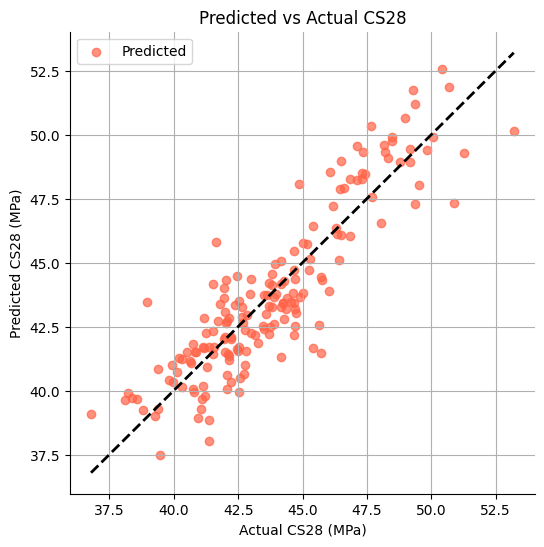

Fold: 2
******
[TRAIN]
******
RMSE: 1.535 (0.000)
MAE: 1.185 (0.000)
MAPE: 0.027 (0.000)
R2: 0.772 (0.000)


******
[TEST]
******
RMSE: 1.535 (0.000)
MAE: 1.185 (0.000)
MAPE: 0.027 (0.000)
R2: 0.772 (0.000)




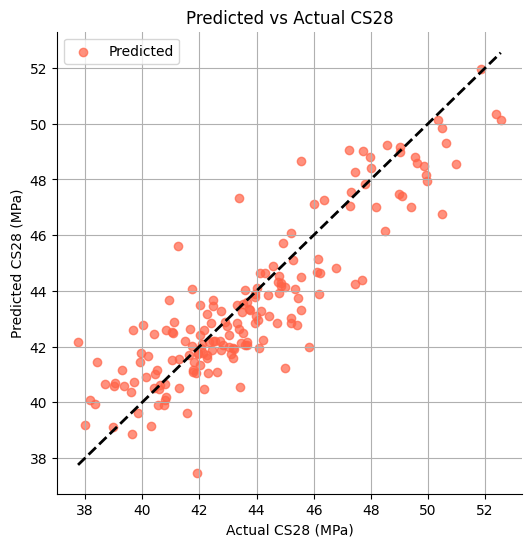

Fold: 3
******
[TRAIN]
******
RMSE: 1.426 (0.000)
MAE: 1.142 (0.000)
MAPE: 0.026 (0.000)
R2: 0.832 (0.000)


******
[TEST]
******
RMSE: 1.426 (0.000)
MAE: 1.142 (0.000)
MAPE: 0.026 (0.000)
R2: 0.832 (0.000)




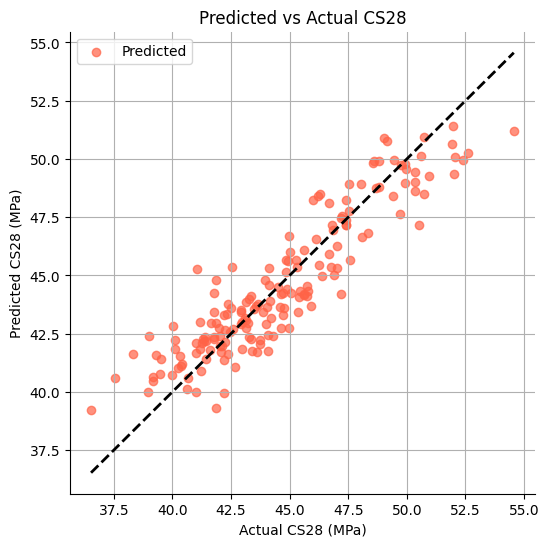

Fold: 4
******
[TRAIN]
******
RMSE: 1.481 (0.000)
MAE: 1.145 (0.000)
MAPE: 0.027 (0.000)
R2: 0.697 (0.000)


******
[TEST]
******
RMSE: 1.481 (0.000)
MAE: 1.145 (0.000)
MAPE: 0.027 (0.000)
R2: 0.697 (0.000)




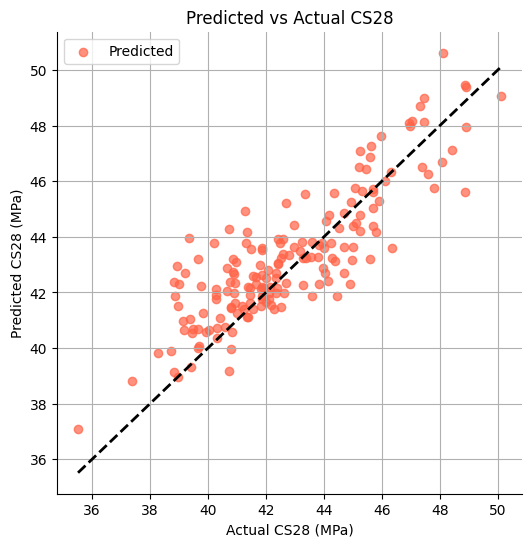

Fold: 5
******
[TRAIN]
******
RMSE: 2.118 (0.000)
MAE: 1.714 (0.000)
MAPE: 0.044 (0.000)
R2: 0.432 (0.000)


******
[TEST]
******
RMSE: 2.118 (0.000)
MAE: 1.714 (0.000)
MAPE: 0.044 (0.000)
R2: 0.432 (0.000)




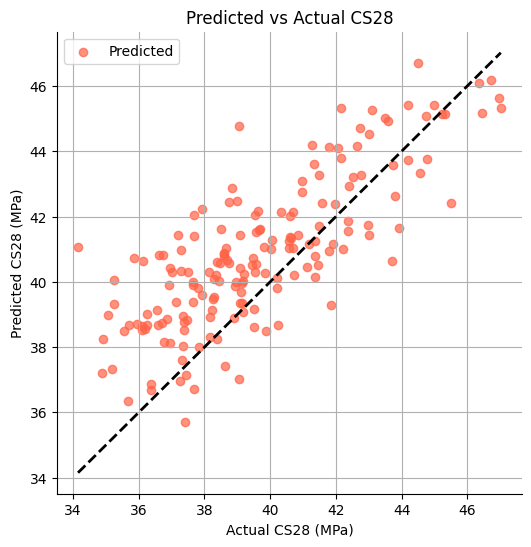

<IPython.core.display.Javascript object>

In [18]:
test_data = df_pred[df_pred["SET"] == "TEST"]

for fold in test_data["FOLD"].unique():
    test_data_f = test_data[test_data["FOLD"].eq(fold)]
    print("Fold:", fold)
    real = test_data_f["CS28"]
    pred = test_data_f["CS28_PRED"]
    results = score_regression_metrics(real, pred, real, pred)
    print_scores(results, METRICS, METRICS_DICT)
    plt.figure(figsize=(6, 6))
    plt.scatter(
        real,
        pred,
        color="tomato",
        alpha=0.7,
        label="Predicted",
    )
    plt.plot(
        [real.min(), real.max()],
        [real.min(), real.max()],
        color="black",
        linestyle="--",
        linewidth=2,
    )
    plt.xlabel("Actual CS28 (MPa)")
    plt.ylabel("Predicted CS28 (MPa)")
    plt.title("Predicted vs Actual CS28")
    plt.legend()
    plt.grid(True)
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.show()

Fold: 1
******
[TRAIN]
******
RMSE: 1.492 (0.000)
MAE: 1.193 (0.000)
MAPE: 0.027 (0.000)
R2: 0.758 (0.000)


******
[TEST]
******
RMSE: 1.492 (0.000)
MAE: 1.193 (0.000)
MAPE: 0.027 (0.000)
R2: 0.758 (0.000)


Fold: 2
******
[TRAIN]
******
RMSE: 1.535 (0.000)
MAE: 1.185 (0.000)
MAPE: 0.027 (0.000)
R2: 0.772 (0.000)


******
[TEST]
******
RMSE: 1.535 (0.000)
MAE: 1.185 (0.000)
MAPE: 0.027 (0.000)
R2: 0.772 (0.000)


Fold: 3
******
[TRAIN]
******
RMSE: 1.426 (0.000)
MAE: 1.142 (0.000)
MAPE: 0.026 (0.000)
R2: 0.832 (0.000)


******
[TEST]
******
RMSE: 1.426 (0.000)
MAE: 1.142 (0.000)
MAPE: 0.026 (0.000)
R2: 0.832 (0.000)


Fold: 4
******
[TRAIN]
******
RMSE: 1.481 (0.000)
MAE: 1.145 (0.000)
MAPE: 0.027 (0.000)
R2: 0.697 (0.000)


******
[TEST]
******
RMSE: 1.481 (0.000)
MAE: 1.145 (0.000)
MAPE: 0.027 (0.000)
R2: 0.697 (0.000)


Fold: 5
******
[TRAIN]
******
RMSE: 2.118 (0.000)
MAE: 1.714 (0.000)
MAPE: 0.044 (0.000)
R2: 0.432 (0.000)


******
[TEST]
******
RMSE: 2.118 (0.000)
MAE: 1.714 (0.

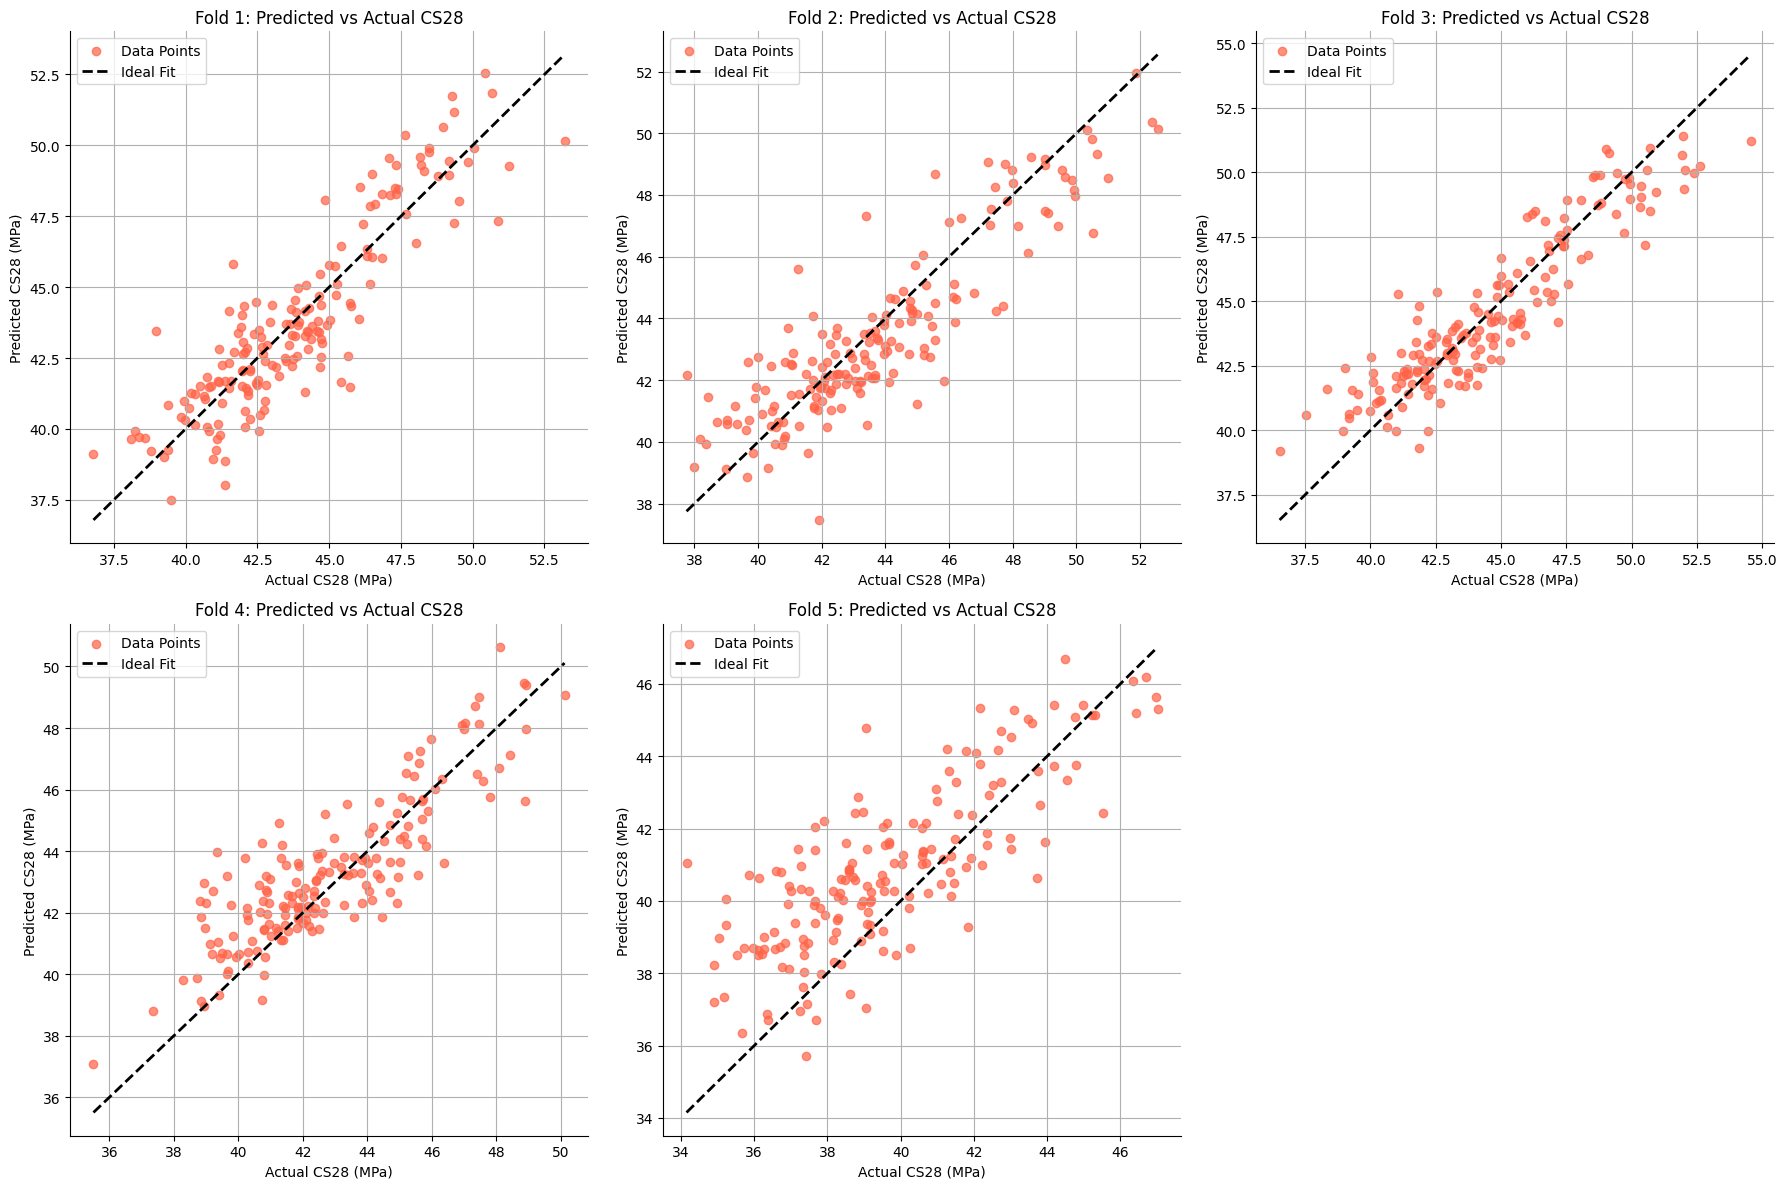

<IPython.core.display.Javascript object>

In [19]:
import matplotlib.pyplot as plt

# Assuming df_pred is already defined and contains your data
test_data = df_pred[df_pred["SET"] == "TEST"]
folds = sorted(test_data["FOLD"].unique())

# Create a figure with subplots: 2 rows x 3 columns
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
axes = axes.flatten()

for i, fold in enumerate(folds):
    test_data_f = test_data[test_data["FOLD"] == fold]
    print("Fold:", fold)
    real = test_data_f["CS28"]
    pred = test_data_f["CS28_PRED"]
    results = score_regression_metrics(real, pred, real, pred)
    print_scores(results, METRICS, METRICS_DICT)
    
    ax = axes[i]
    ax.scatter(
        real,
        pred,
        color="tomato",
        alpha=0.7,
        label="Data Points",
    )
    ax.plot(
        [real.min(), real.max()],
        [real.min(), real.max()],
        color="black",
        linestyle="--",
        linewidth=2,
        label="Ideal Fit",
    )
    ax.set_xlabel("Actual CS28 (MPa)")
    ax.set_ylabel("Predicted CS28 (MPa)")
    ax.set_title(f"Fold {fold}: Predicted vs Actual CS28")
    ax.legend()
    ax.grid(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Remove any unused subplots if the number of folds is less than the number of subplots
for j in range(len(folds), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Fold: 1
******
[TRAIN]
******
RMSE: 1.492 (0.000)
MAE: 1.193 (0.000)
MAPE: 0.027 (0.000)
R2: 0.758 (0.000)


******
[TEST]
******
RMSE: 1.492 (0.000)
MAE: 1.193 (0.000)
MAPE: 0.027 (0.000)
R2: 0.758 (0.000)


Fold: 2
******
[TRAIN]
******
RMSE: 1.535 (0.000)
MAE: 1.185 (0.000)
MAPE: 0.027 (0.000)
R2: 0.772 (0.000)


******
[TEST]
******
RMSE: 1.535 (0.000)
MAE: 1.185 (0.000)
MAPE: 0.027 (0.000)
R2: 0.772 (0.000)


Fold: 3
******
[TRAIN]
******
RMSE: 1.426 (0.000)
MAE: 1.142 (0.000)
MAPE: 0.026 (0.000)
R2: 0.832 (0.000)


******
[TEST]
******
RMSE: 1.426 (0.000)
MAE: 1.142 (0.000)
MAPE: 0.026 (0.000)
R2: 0.832 (0.000)


Fold: 4
******
[TRAIN]
******
RMSE: 1.481 (0.000)
MAE: 1.145 (0.000)
MAPE: 0.027 (0.000)
R2: 0.697 (0.000)


******
[TEST]
******
RMSE: 1.481 (0.000)
MAE: 1.145 (0.000)
MAPE: 0.027 (0.000)
R2: 0.697 (0.000)


Fold: 5
******
[TRAIN]
******
RMSE: 2.118 (0.000)
MAE: 1.714 (0.000)
MAPE: 0.044 (0.000)
R2: 0.432 (0.000)


******
[TEST]
******
RMSE: 2.118 (0.000)
MAE: 1.714 (0.

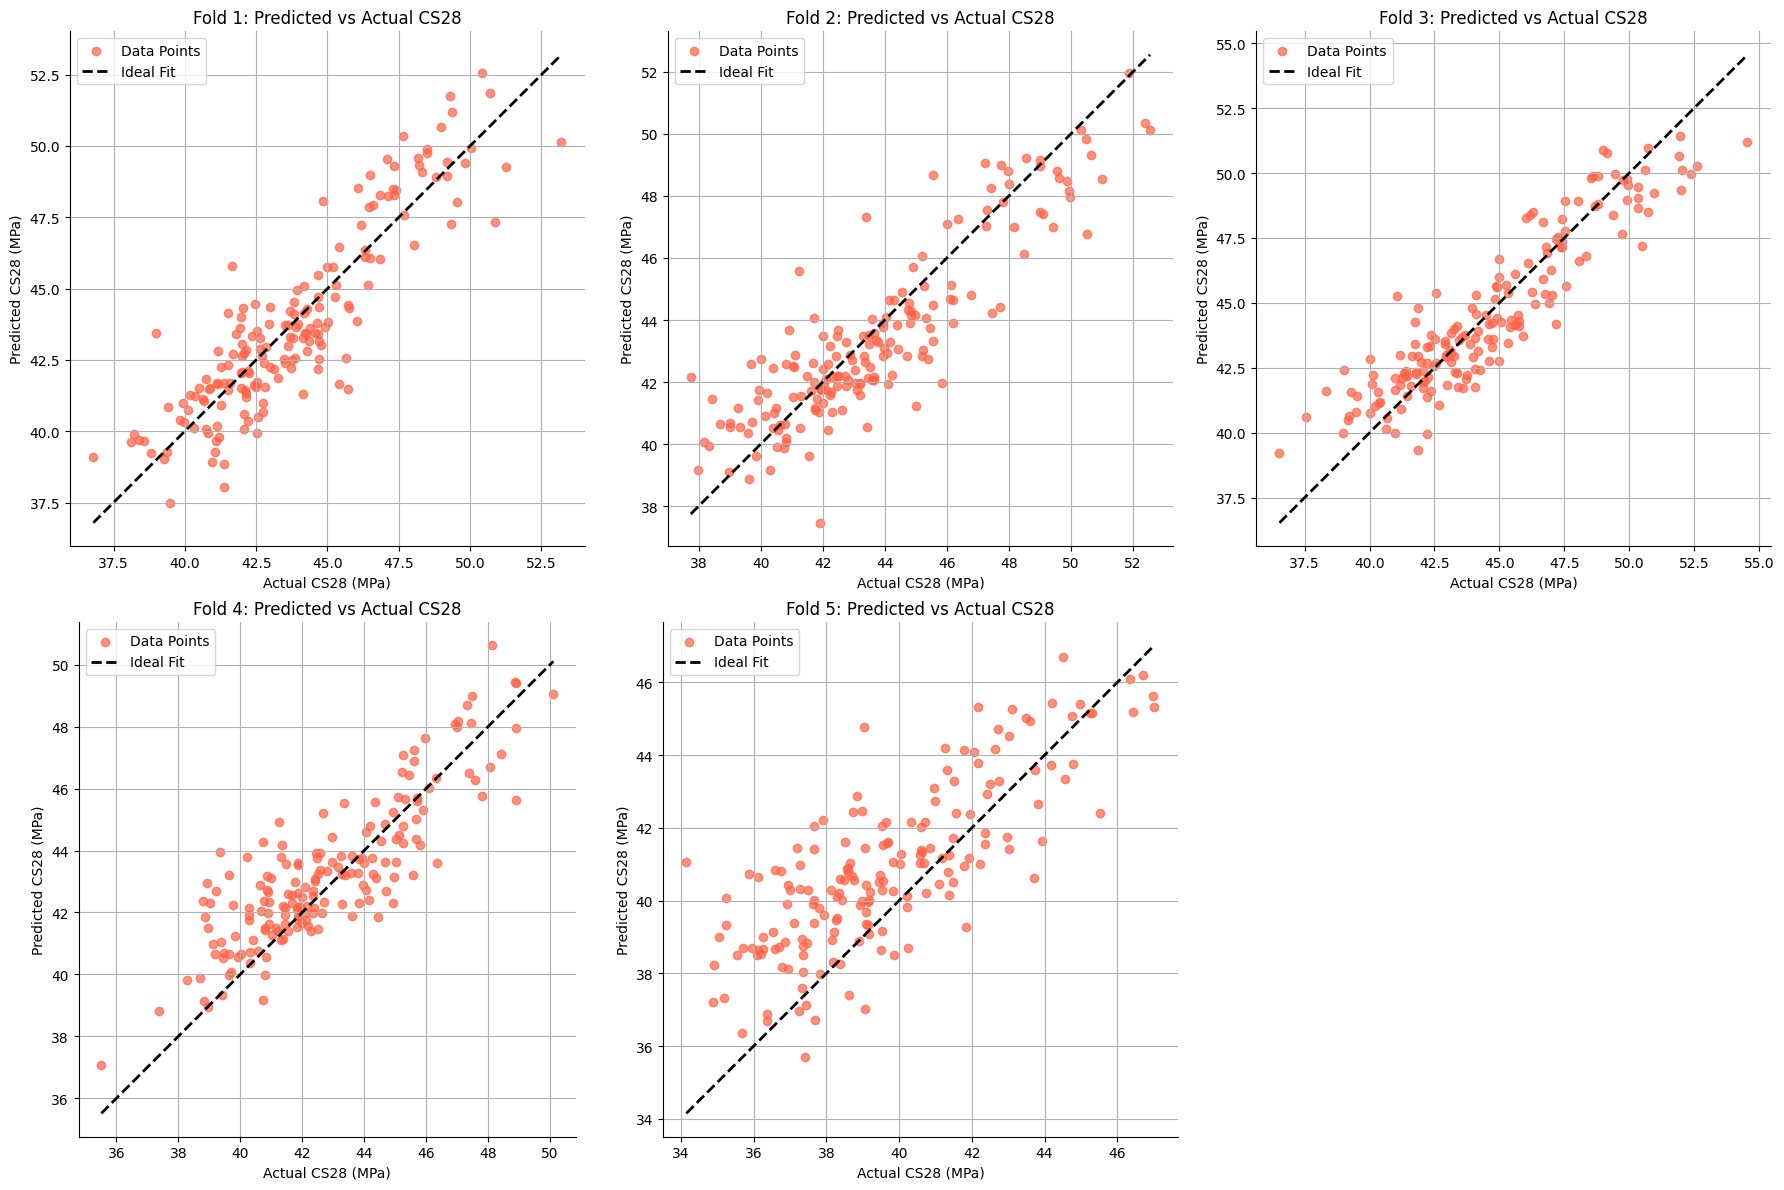

<IPython.core.display.Javascript object>

In [20]:
import matplotlib.pyplot as plt

# Assuming df_pred is already defined and contains your data
test_data = df_pred[df_pred["SET"] == "TEST"]
folds = sorted(test_data["FOLD"].unique())

# Number of folds
num_folds = len(folds)

# Determine the number of rows and columns for subplots
# For 5 folds, we'll use a 2x3 grid (will have one empty subplot)
cols = 3
rows = 2

# Create a figure with subplots: adjust figsize to ensure square subplots
fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(cols * 6, rows * 6))
axes = axes.flatten()

for i, fold in enumerate(folds):
    test_data_f = test_data[test_data["FOLD"] == fold]
    print("Fold:", fold)
    real = test_data_f["CS28"]
    pred = test_data_f["CS28_PRED"]
    results = score_regression_metrics(real, pred, real, pred)
    print_scores(results, METRICS, METRICS_DICT)
    
    ax = axes[i]
    ax.scatter(
        real,
        pred,
        color="tomato",
        alpha=0.7,
        label="Data Points",
    )
    ax.plot(
        [real.min(), real.max()],
        [real.min(), real.max()],
        color="black",
        linestyle="--",
        linewidth=2,
        label="Ideal Fit",
    )
    ax.set_xlabel("Actual CS28 (MPa)")
    ax.set_ylabel("Predicted CS28 (MPa)")
    ax.set_title(f"Fold {fold}: Predicted vs Actual CS28")
    ax.legend()
    ax.grid(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_aspect('equal', adjustable='box')  # Ensure the subplot is square

# Remove any unused subplots if the number of folds is less than the number of subplots
for j in range(num_folds, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


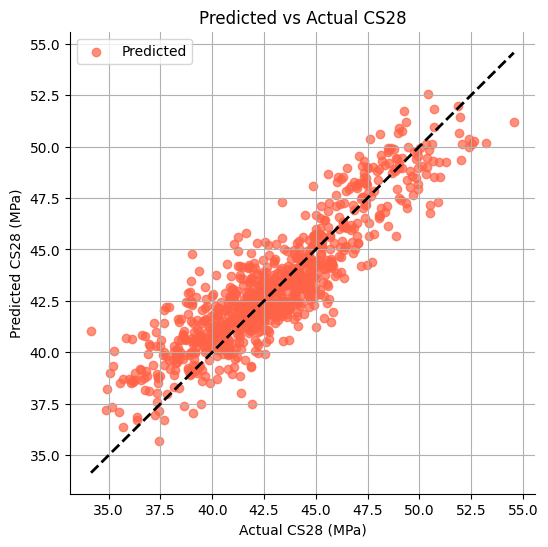

<IPython.core.display.Javascript object>

In [21]:
# Scatter plot of actual vs predicted values
test_data = df_pred[df_pred["SET"] == "TEST"]
plt.figure(figsize=(6, 6))
plt.scatter(
    test_data["CS28"],
    test_data["CS28_PRED"],
    color="tomato",
    alpha=0.7,
    label="Predicted",
)
plt.plot(
    [test_data["CS28"].min(), test_data["CS28"].max()],
    [test_data["CS28"].min(), test_data["CS28"].max()],
    color="black",
    linestyle="--",
    linewidth=2,
)
plt.xlabel("Actual CS28 (MPa)")
plt.ylabel("Predicted CS28 (MPa)")
plt.title("Predicted vs Actual CS28")
plt.legend()
plt.grid(True)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.savefig(
    "inn_cm_p_cs_tiss_scpm_top_one_pred_vs_actual_cs28.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

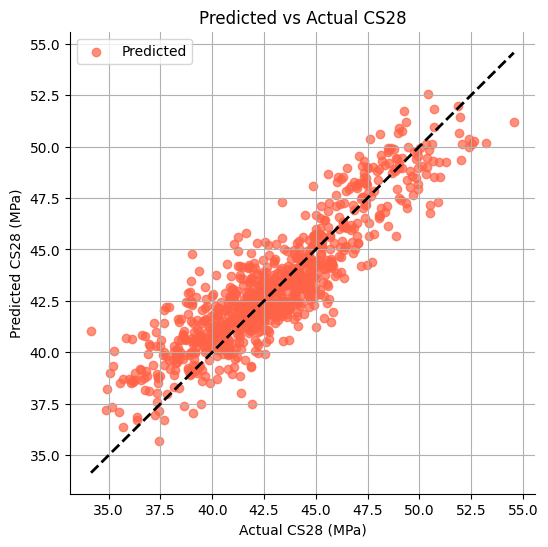

<IPython.core.display.Javascript object>

In [22]:
# Scatter plot of actual vs predicted values
test_data = df_pred[df_pred["SET"] == "TEST"]
plt.figure(figsize=(6, 6))
plt.scatter(
    test_data["CS28"],
    test_data["CS28_PRED"],
    color="tomato",
    alpha=0.7,
    label="Predicted",
)
plt.plot(
    [test_data["CS28"].min(), test_data["CS28"].max()],
    [test_data["CS28"].min(), test_data["CS28"].max()],
    color="black",
    linestyle="--",
    linewidth=2,
)
plt.xlabel("Actual CS28 (MPa)")
plt.ylabel("Predicted CS28 (MPa)")
plt.title("Predicted vs Actual CS28")
plt.legend()
plt.grid(True)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.savefig(
    "inn_cm_p_cs_tiss_scpm_top_one_pred_vs_actual_cs28.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

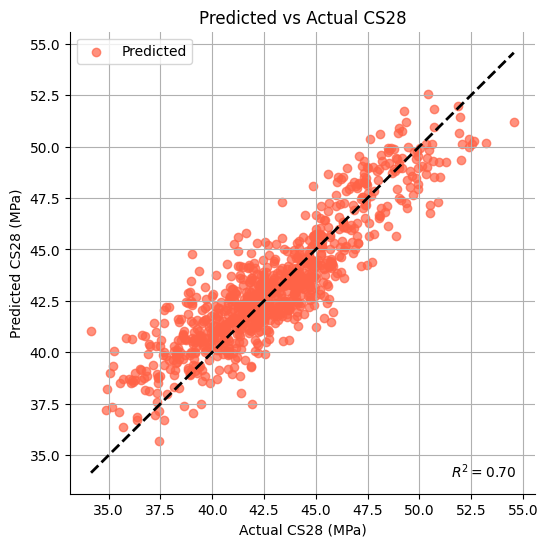

<IPython.core.display.Javascript object>

In [23]:
# Scatter plot of actual vs predicted values
test_data = df_pred[df_pred["SET"] == "TEST"]
plt.figure(figsize=(6, 6))
plt.scatter(
    test_data["CS28"],
    test_data["CS28_PRED"],
    color="tomato",
    alpha=0.7,
    label="Predicted",
)
plt.plot(
    [test_data["CS28"].min(), test_data["CS28"].max()],
    [test_data["CS28"].min(), test_data["CS28"].max()],
    color="black",
    linestyle="--",
    linewidth=2,
)
plt.xlabel("Actual CS28 (MPa)")
plt.ylabel("Predicted CS28 (MPa)")
plt.title("Predicted vs Actual CS28")
plt.legend()
plt.grid(True)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

r2 = 0.70
plt.text(
    0.82,
    0.07,
    f"$R^2 = {r2:.2f}$",
    transform=plt.gca().transAxes,
    verticalalignment="top",
)

plt.savefig(
    "inn_cm_p_cs_tiss_scpm_top_one_pred_vs_actual_cs28.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

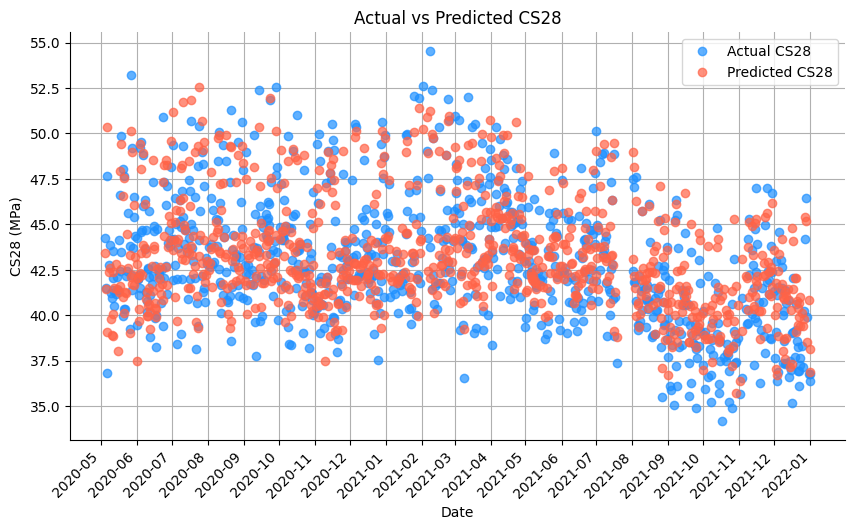

<IPython.core.display.Javascript object>

In [24]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(10, 6))
plt.plot(
    test_data["DATE"],
    test_data["CS28"],
    color="dodgerblue",
    alpha=0.7,
    marker="o",
    linestyle="none",
    label="Actual CS28",
)
plt.plot(
    test_data["DATE"],
    test_data["CS28_PRED"],
    color="tomato",
    alpha=0.7,
    marker="o",
    linestyle="none",
    label="Predicted CS28",
)
plt.xlabel("Date")
plt.ylabel("CS28 (MPa)")
plt.title("Actual vs Predicted CS28")
plt.legend()
plt.grid(True)

# Improving x-axis readability
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())  # Set ticks for each month
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # Format date as 'YYYY-MM-DD'
plt.gcf().autofmt_xdate(rotation=45)  # Rotate x-axis labels

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.savefig(
    "inn_cm_p_cs_tiss_scpm_top_one_pred_vs_actual_cs28_over_time.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


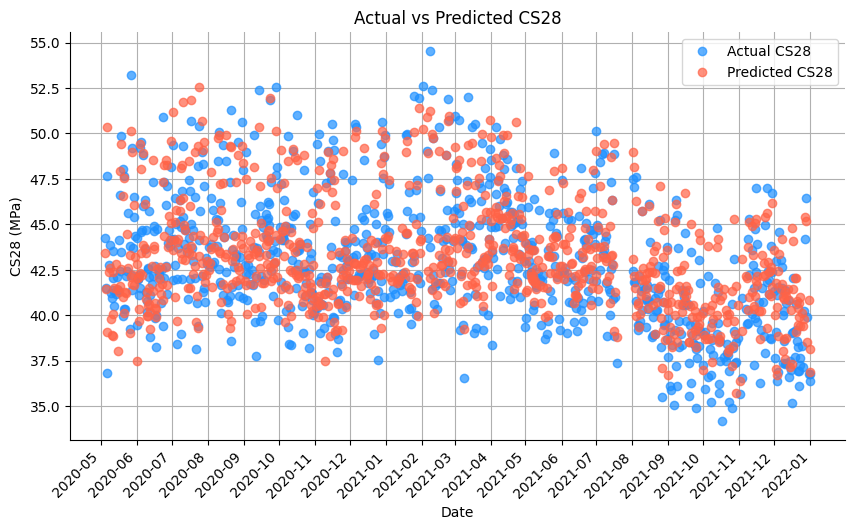

<IPython.core.display.Javascript object>

In [25]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(10, 6))
plt.plot(
    test_data["DATE"],
    test_data["CS28"],
    color="dodgerblue",
    alpha=0.7,
    marker="o",
    linestyle="none",
    label="Actual CS28",
)
plt.plot(
    test_data["DATE"],
    test_data["CS28_PRED"],
    color="tomato",
    alpha=0.7,
    marker="o",
    linestyle="none",
    label="Predicted CS28",
)
plt.xlabel("Date")
plt.ylabel("CS28 (MPa)")
plt.title("Actual vs Predicted CS28")
plt.legend()
plt.grid(True)

# Improving x-axis readability
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())  # Set ticks for each month
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # Format date as 'YYYY-MM-DD'
plt.gcf().autofmt_xdate(rotation=45)  # Rotate x-axis labels

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.savefig(
    "inn_cm_p_cs_tiss_scpm_top_one_pred_vs_actual_cs28_over_time.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


## Assessing Feature Importance

In [26]:
df_coefs, df_bias = get_linreg_df_importances(scores)
df_importances = df_coefs

<IPython.core.display.Javascript object>

In [27]:
df_importances

,CaO,SiO2,Al2O3,Fe2O3,MgO,SO3,K2O,Na2O,Total C3S,Total C2S,...,C4AF,Free CaO,Loss on Ignition,Initial setting time,CS1,CS3,CS7,Blaine,Sieve 32 um,Sieve 45 um
Coefficients - 0,0.137040,-0.368341,0.796098,0.137435,-0.154098,-0.016447,-0.509059,0.008905,0.514784,0.813740,...,-0.760953,-0.014602,-0.141184,0.008502,1.217085,1.362620,1.904580,-0.936871,0.342335,0.285218
Coefficients - 1,0.198462,-0.136658,-0.008539,0.116892,-0.095876,-0.118335,-0.240227,0.086478,-0.151207,0.347978,...,-0.444516,-0.291841,-0.185002,-0.329795,0.854919,1.092543,2.074235,-0.795732,0.176664,-0.145951
Coefficients - 2,0.082579,-0.101177,0.083278,-0.037905,-0.024412,-0.082268,-0.332718,-0.064821,0.158079,0.560300,...,-0.134677,-0.142936,-0.103712,-0.277308,0.877898,1.241233,1.882778,-0.922229,0.307116,-0.037012
Coefficients - 3,0.141056,-0.081788,0.005822,0.007523,-0.020981,-0.054395,-0.316657,-0.034819,0.458026,0.849415,...,-0.051390,-0.069561,0.053260,-0.125528,1.109533,1.201562,2.026192,-1.086089,0.345863,0.027974
Coefficients - 4,0.161331,0.009811,-0.044789,0.053205,-0.110259,-0.038480,-0.285000,-0.080397,0.327577,0.694911,...,-0.097015,-0.049637,0.011358,-0.124405,0.764320,1.260689,2.004441,-0.903927,0.283059,0.021991


<IPython.core.display.Javascript object>

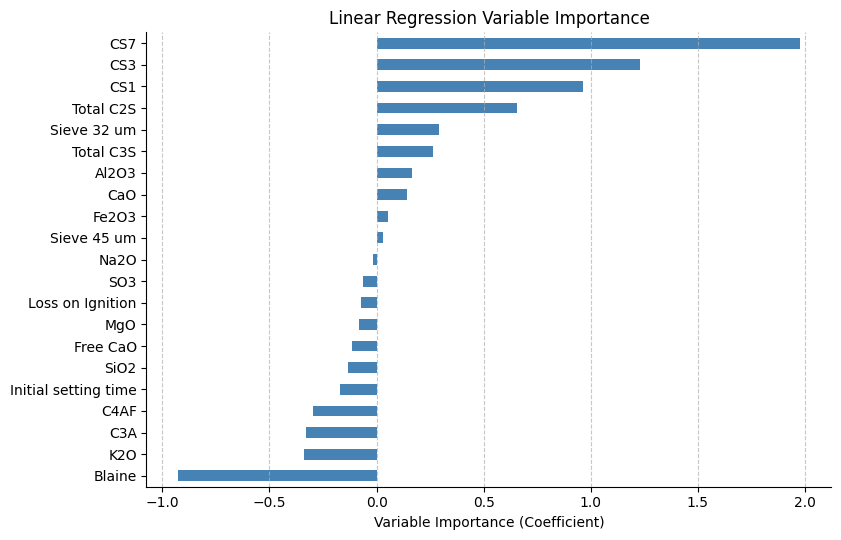

<IPython.core.display.Javascript object>

In [28]:
df_importances.mean(axis=0).sort_values().plot(
    kind="barh", figsize=(10, 5.5), color="steelblue"  # Consider using 'steelblue'
)
plt.title("Linear Regression Variable Importance")
plt.xlabel("Variable Importance (Coefficient)")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.subplots_adjust(left=0.3)
plt.show()

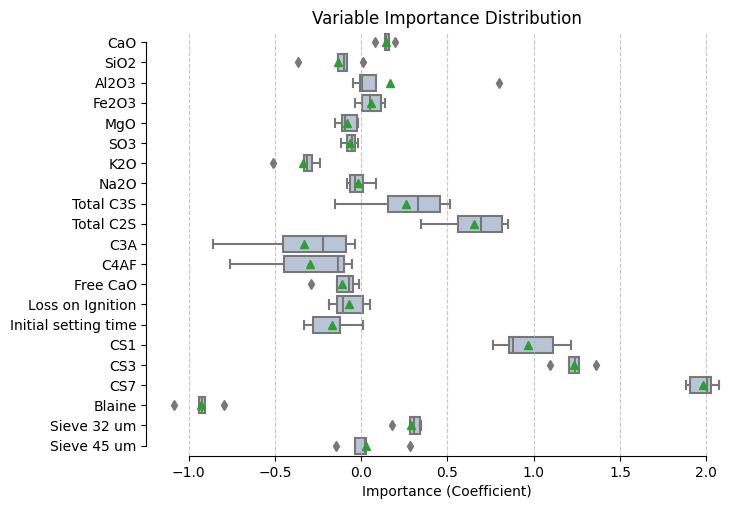

<IPython.core.display.Javascript object>

In [29]:
warnings.filterwarnings("ignore")
plt.figure(figsize=(10, 5.5))
sns.boxplot(data=df_importances, orient="h", color="lightsteelblue", saturation=0.7, showmeans=True)
sns.despine(trim=True, left=False)
plt.xlabel("Importance (Coefficient)")
plt.title("Variable Importance Distribution")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.subplots_adjust(left=0.3)
plt.show()


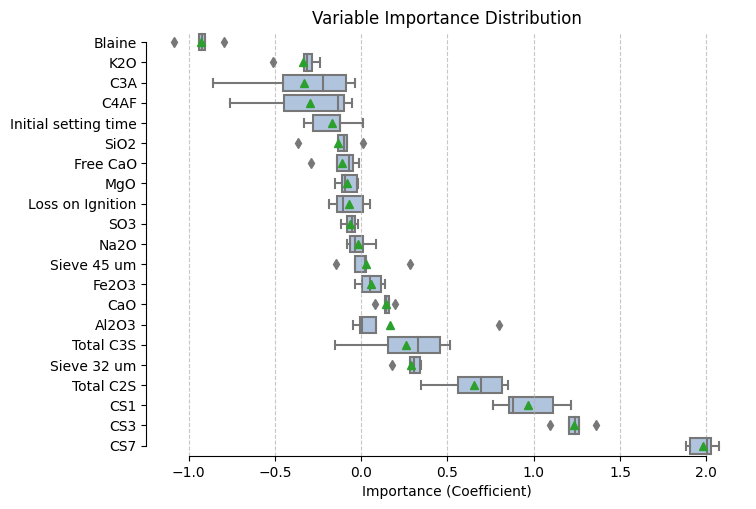

<IPython.core.display.Javascript object>

In [30]:
# Calculate the means of the importance scores
mean_importances = df_importances.mean()

# Sort the features by their mean relevance
sorted_features = mean_importances.sort_values()

# Re-order the DataFrame according to the sorted features
df_importances_sorted = df_importances[sorted_features.index]

# Plot the sorted boxplot
# df_importances_sorted = df_importances_sorted.rename(
#    columns={"Loss on Ignition": "LOI"}
# )

plt.figure(figsize=(10, 5.5))
sns.boxplot(
    data=df_importances_sorted,
    orient="h",
    color="lightsteelblue",
    saturation=1,
    showmeans=True,
)
sns.despine(trim=True, left=False)
plt.xlabel("Importance (Coefficient)")
plt.title("Variable Importance Distribution")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.subplots_adjust(left=0.3)
plt.savefig(
    "inn_cm_p_cs_tiss_linear_regression_scpm_best_dist_var_relevance.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [31]:
print("Default font family:", matplotlib.rcParams["font.family"])
print("Default sans-serif fonts:", matplotlib.rcParams["font.sans-serif"])
print("Default font size:", matplotlib.rcParams["font.size"])
print("Default font weight:", matplotlib.rcParams["font.weight"])

Default font family: ['sans-serif']
Default sans-serif fonts: ['DejaVu Sans', 'Bitstream Vera Sans', 'Computer Modern Sans Serif', 'Lucida Grande', 'Verdana', 'Geneva', 'Lucid', 'Arial', 'Helvetica', 'Avant Garde', 'sans-serif']
Default font size: 10.0
Default font weight: normal


<IPython.core.display.Javascript object>

In [32]:
plt.get_backend()

'module://matplotlib_inline.backend_inline'

<IPython.core.display.Javascript object>

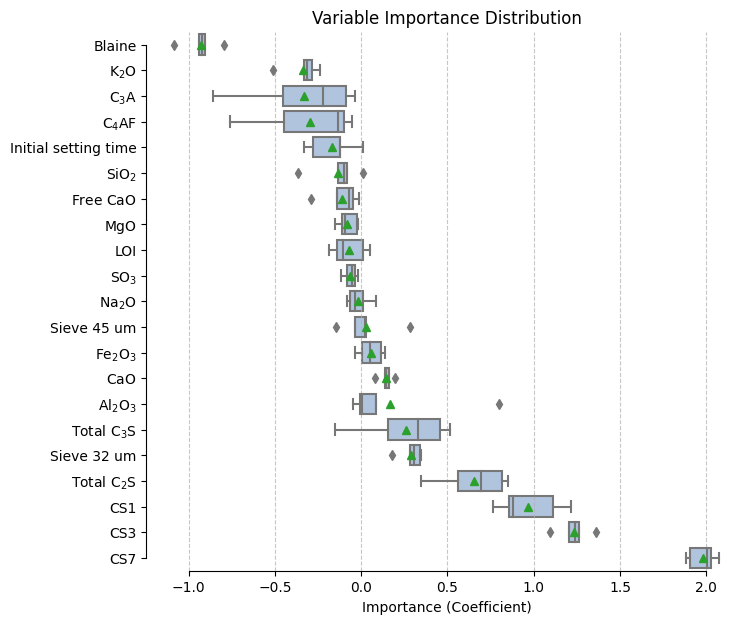

<IPython.core.display.Javascript object>

In [33]:
# Backup the original backend
original_backend = plt.get_backend()

# Use Matplotlib's default backend
# plt.switch_backend("agg")  # or any backend you prefer

# Update font settings to default
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["DejaVu Sans"],
        "font.size": 10,
        "text.usetex": False,  # Use MathText, not LaTeX
    }
)


# Convert chemical formulas using MathText syntax
df_importances_sorted_plot = df_importances_sorted.rename(
    columns={
        "Alpha C2S": r"Alpha $\mathrm{C_2S}$",
        "Beta C2S": r"Beta $\mathrm{C_2S}$",
        "Gamma C2S": r"Gamma $\mathrm{C_2S}$",
        "Cubic C3A": r"Cubic $\mathrm{C_3A}$",
        "Orthorhombic C3A": r"Orthorhombic $\mathrm{C_3A}$",
        "K2O": r"$\mathrm{K_2O}$",
        "Free CaO": r"Free $\mathrm{CaO}$",
        "Total C2S": r"Total $\mathrm{C_2S}$",
        "Na2O": r"$\mathrm{Na_2O}$",
        "CaO": r"$\mathrm{CaO}$",
        "SiO2": r"$\mathrm{SiO_2}$",
        "MgO": r"$\mathrm{MgO}$",
        "Fe2O3": r"$\mathrm{Fe_2O_3}$",
        "Al2O3": r"$\mathrm{Al_2O_3}$",
        "Total C3S": r"Total $\mathrm{C_3S}$",
        "C3A": r"$\mathrm{C_3A}$",
        "C4AF": r"$\mathrm{C_4AF}$",
        "LOI": "LOI",
        "SO3": r"$\mathrm{SO_3}$",
        "Insoluble Residue": "IR",
        "Loss on Ignition": "LOI",
    }
)

plt.figure(figsize=(10, 7))
sns.boxplot(
    data=df_importances_sorted_plot,
    orient="h",
    color="lightsteelblue",
    saturation=1,
    showmeans=True,
)
sns.despine(trim=True, left=False)
plt.xlabel("Importance (Coefficient)")
plt.title("Variable Importance Distribution")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.subplots_adjust(left=0.3)
plt.savefig(
    "inn_cm_p_cs_tiss_linear_regression_scpm_best_dist_var_relevance.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


# Step 3: Reset all rcParams to their default values
matplotlib.rcParams.update(matplotlib.rcParamsDefault)
plt.rcdefaults()

# Switch back to the original backend
plt.switch_backend(original_backend)

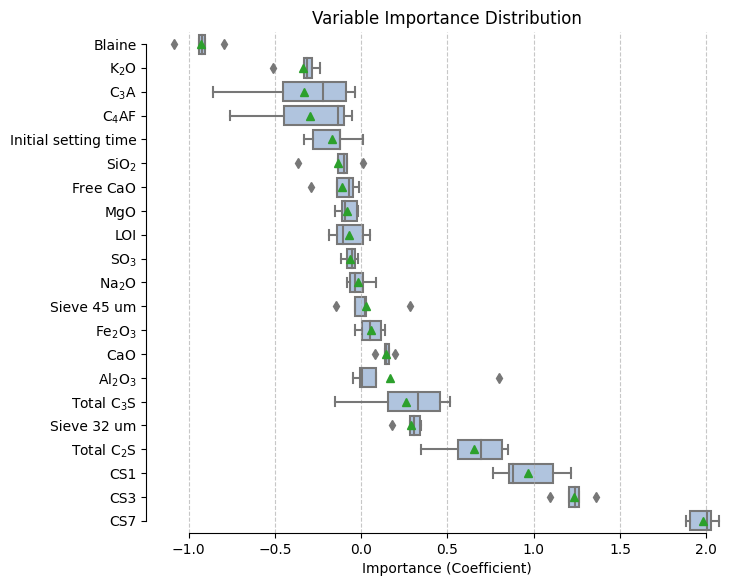

<IPython.core.display.Javascript object>

In [34]:
# Backup the original backend
original_backend = plt.get_backend()

# Use Matplotlib's default backend
# plt.switch_backend("agg")  # or any backend you prefer

# Update font settings to default
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["DejaVu Sans"],
        "font.size": 10,
        "text.usetex": False,  # Use MathText, not LaTeX
    }
)


# Convert chemical formulas using MathText syntax
df_importances_sorted_plot = df_importances_sorted.rename(
    columns={
        "Alpha C2S": r"Alpha $\mathrm{C_2S}$",
        "Beta C2S": r"Beta $\mathrm{C_2S}$",
        "Gamma C2S": r"Gamma $\mathrm{C_2S}$",
        "Cubic C3A": r"Cubic $\mathrm{C_3A}$",
        "Orthorhombic C3A": r"Orthorhombic $\mathrm{C_3A}$",
        "K2O": r"$\mathrm{K_2O}$",
        "Free CaO": r"Free $\mathrm{CaO}$",
        "Total C2S": r"Total $\mathrm{C_2S}$",
        "Na2O": r"$\mathrm{Na_2O}$",
        "CaO": r"$\mathrm{CaO}$",
        "SiO2": r"$\mathrm{SiO_2}$",
        "MgO": r"$\mathrm{MgO}$",
        "Fe2O3": r"$\mathrm{Fe_2O_3}$",
        "Al2O3": r"$\mathrm{Al_2O_3}$",
        "Total C3S": r"Total $\mathrm{C_3S}$",
        "C3A": r"$\mathrm{C_3A}$",
        "C4AF": r"$\mathrm{C_4AF}$",
        "LOI": "LOI",
        "SO3": r"$\mathrm{SO_3}$",
        "Insoluble Residue": "IR",
        "Loss on Ignition": "LOI",
    }
)

plt.figure(figsize=(10, 6.5))
sns.boxplot(
    data=df_importances_sorted_plot,
    orient="h",
    color="lightsteelblue",
    saturation=1,
    showmeans=True,
)
sns.despine(trim=True, left=False)
plt.xlabel("Importance (Coefficient)")
plt.title("Variable Importance Distribution")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.subplots_adjust(left=0.3)

plt.show()


# Step 3: Reset all rcParams to their default values
matplotlib.rcParams.update(matplotlib.rcParamsDefault)
plt.rcdefaults()

# Switch back to the original backend
plt.switch_backend(original_backend)

In [35]:
df_importances

,CaO,SiO2,Al2O3,Fe2O3,MgO,SO3,K2O,Na2O,Total C3S,Total C2S,...,C4AF,Free CaO,Loss on Ignition,Initial setting time,CS1,CS3,CS7,Blaine,Sieve 32 um,Sieve 45 um
Coefficients - 0,0.137040,-0.368341,0.796098,0.137435,-0.154098,-0.016447,-0.509059,0.008905,0.514784,0.813740,...,-0.760953,-0.014602,-0.141184,0.008502,1.217085,1.362620,1.904580,-0.936871,0.342335,0.285218
Coefficients - 1,0.198462,-0.136658,-0.008539,0.116892,-0.095876,-0.118335,-0.240227,0.086478,-0.151207,0.347978,...,-0.444516,-0.291841,-0.185002,-0.329795,0.854919,1.092543,2.074235,-0.795732,0.176664,-0.145951
Coefficients - 2,0.082579,-0.101177,0.083278,-0.037905,-0.024412,-0.082268,-0.332718,-0.064821,0.158079,0.560300,...,-0.134677,-0.142936,-0.103712,-0.277308,0.877898,1.241233,1.882778,-0.922229,0.307116,-0.037012
Coefficients - 3,0.141056,-0.081788,0.005822,0.007523,-0.020981,-0.054395,-0.316657,-0.034819,0.458026,0.849415,...,-0.051390,-0.069561,0.053260,-0.125528,1.109533,1.201562,2.026192,-1.086089,0.345863,0.027974
Coefficients - 4,0.161331,0.009811,-0.044789,0.053205,-0.110259,-0.038480,-0.285000,-0.080397,0.327577,0.694911,...,-0.097015,-0.049637,0.011358,-0.124405,0.764320,1.260689,2.004441,-0.903927,0.283059,0.021991


<IPython.core.display.Javascript object>

In [36]:
df_importances.describe().T.sort_values(by=["mean"])

,count,mean,std,min,25%,50%,75%,max
Blaine,5.0,-0.928970,0.103891,-1.086089,-0.936871,-0.922229,-0.903927,-0.795732
K2O,5.0,-0.336732,0.102598,-0.509059,-0.332718,-0.316657,-0.285000,-0.240227
C3A,5.0,-0.330860,0.335769,-0.857120,-0.453760,-0.220963,-0.087937,-0.034518
C4AF,5.0,-0.297710,0.301529,-0.760953,-0.444516,-0.134677,-0.097015,-0.051390
Initial setting time,5.0,-0.169707,0.135064,-0.329795,-0.277308,-0.125528,-0.124405,0.008502
SiO2,5.0,-0.135631,0.140885,-0.368341,-0.136658,-0.101177,-0.081788,0.009811
Free CaO,5.0,-0.113715,0.110070,-0.291841,-0.142936,-0.069561,-0.049637,-0.014602
MgO,5.0,-0.081125,0.057500,-0.154098,-0.110259,-0.095876,-0.024412,-0.020981
Loss on Ignition,5.0,-0.073056,0.101482,-0.185002,-0.141184,-0.103712,0.011358,0.053260
SO3,5.0,-0.061985,0.039593,-0.118335,-0.082268,-0.054395,-0.038480,-0.016447


<IPython.core.display.Javascript object>

In [37]:
df_importances.mean(axis=0)

CaO                     0.144094
SiO2                   -0.135631
Al2O3                   0.166374
Fe2O3                   0.055430
MgO                    -0.081125
SO3                    -0.061985
K2O                    -0.336732
Na2O                   -0.016931
Total C3S               0.261452
Total C2S               0.653269
C3A                    -0.330860
C4AF                   -0.297710
Free CaO               -0.113715
Loss on Ignition       -0.073056
Initial setting time   -0.169707
CS1                     0.964751
CS3                     1.231729
CS7                     1.978445
Blaine                 -0.928970
Sieve 32 um             0.291007
Sieve 45 um             0.030444
dtype: float64

<IPython.core.display.Javascript object>

In [38]:
df_importances.std(axis=0)

CaO                     0.042119
SiO2                    0.140885
Al2O3                   0.355112
Fe2O3                   0.073338
MgO                     0.057500
SO3                     0.039593
K2O                     0.102598
Na2O                    0.067087
Total C3S               0.268405
Total C2S               0.204819
C3A                     0.335769
C4AF                    0.301529
Free CaO                0.110070
Loss on Ignition        0.101482
Initial setting time    0.135064
CS1                     0.190009
CS3                     0.097908
CS7                     0.081761
Blaine                  0.103891
Sieve 32 um             0.068994
Sieve 45 um             0.158629
dtype: float64

<IPython.core.display.Javascript object>

In [39]:
df_importances.std(axis=0, ddof=0)

CaO                     0.037672
SiO2                    0.126011
Al2O3                   0.317622
Fe2O3                   0.065595
MgO                     0.051430
SO3                     0.035413
K2O                     0.091766
Na2O                    0.060004
Total C3S               0.240069
Total C2S               0.183196
C3A                     0.300321
C4AF                    0.269695
Free CaO                0.098450
Loss on Ignition        0.090768
Initial setting time    0.120805
CS1                     0.169949
CS3                     0.087572
CS7                     0.073129
Blaine                  0.092923
Sieve 32 um             0.061710
Sieve 45 um             0.141882
dtype: float64

<IPython.core.display.Javascript object>

In [40]:
df_copy.nunique()

Date                    693
CaO                     226
SiO2                    182
Al2O3                    89
Fe2O3                    56
MgO                     178
SO3                      78
K2O                      32
Na2O                     18
Total C3S               630
Total C2S               561
C3A                     232
C4AF                    224
Free CaO                 98
Loss on Ignition        173
Initial setting time     23
CS1                     523
CS3                     647
CS7                     684
Blaine                  149
Sieve 32 um             538
Sieve 45 um             409
dtype: int64

<IPython.core.display.Javascript object>

In [41]:
pipeline.named_steps

{'imputer': SimpleImputer(strategy='median'),
 'transformer': StandardScaler(),
 'estimator': LinearRegression()}

<IPython.core.display.Javascript object>

In [42]:
from sklearn.inspection import permutation_importance

<IPython.core.display.Javascript object>

In [43]:
# Initialize lists to store importance results
mdi_importances = []
perm_importances = []

# Compute feature importances
for i, (train_idx, test_idx) in enumerate(cv.split(x, y)):
    pipeline.fit(x.iloc[train_idx], y[train_idx])

    # Extract the trained model
    model = pipeline.named_steps["estimator"]
    imputer = pipeline.named_steps["imputer"]
    scaler = pipeline.named_steps["transformer"]
    # Compute MDI importance
    # mdi_importances.append(model.feature_importances_)

    # Compute permutation importance
    result = permutation_importance(
        model,
        scaler.transform(imputer.transform(x.iloc[test_idx])),
        y[test_idx],
        n_repeats=10,
        random_state=SEED,
        n_jobs=-1,
        # scoring="neg_mean_squared_error",
        scoring="r2",
    )
    perm_importances.append(result.importances_mean)

<IPython.core.display.Javascript object>

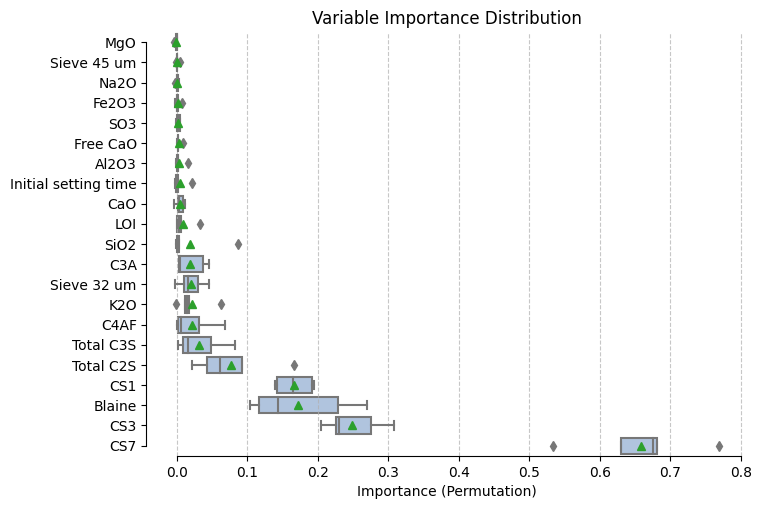

<IPython.core.display.Javascript object>

In [44]:
# Convert lists to DataFrames
# mdi_importances_df = pd.DataFrame(mdi_importances, columns=x.columns)
perm_importances_df = pd.DataFrame(perm_importances, columns=x.columns)


# Calculate the mean importance for each feature
mean_importances = perm_importances_df.mean().sort_values()

# Reorder the DataFrame columns based on mean importance
perm_importances_df = perm_importances_df[mean_importances.index]

perm_importances_df = perm_importances_df.rename(
    columns={"Loss on Ignition": "LOI", "Insoluble Residue": "IR"}
)


plt.figure(figsize=(10, 5.5))
sns.boxplot(
    data=perm_importances_df,
    orient="h",
    color="lightsteelblue",
    saturation=1,
    showmeans=True,
)
sns.despine(trim=True, left=False)
plt.xlabel("Importance (Permutation)")
plt.title("Variable Importance Distribution")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.subplots_adjust(left=0.3)
plt.savefig(
    "inn_cm_p_cs_tiss_linear_regression_scpm_best_dist_var_perm_relevance.png",
    dpi=300,
    bbox_inches="tight",
)

# # Step 3: Reset all rcParams to their default values
plt.rcdefaults()

plt.show()

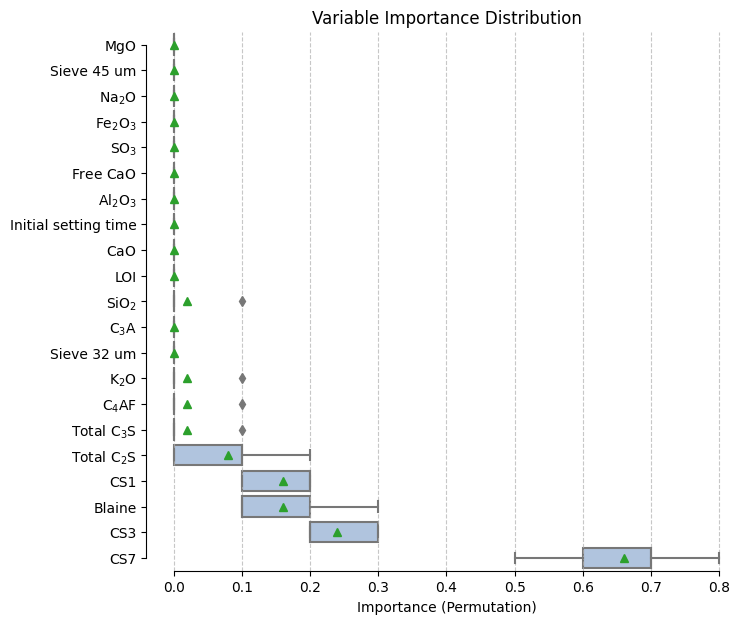

<IPython.core.display.Javascript object>

In [45]:
# Backup the original backend
original_backend = plt.get_backend()

# Use Matplotlib's default backend
# plt.switch_backend("agg")  # or any backend you prefer

# Update font settings to default
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["DejaVu Sans"],
        "font.size": 10,
        "text.usetex": False,  # Use MathText, not LaTeX
    }
)


# Convert chemical formulas using MathText syntax
perm_importances_df_plot = perm_importances_df.rename(
    columns={
        "Alpha C2S": r"Alpha $\mathrm{C_2S}$",
        "Beta C2S": r"Beta $\mathrm{C_2S}$",
        "Gamma C2S": r"Gamma $\mathrm{C_2S}$",
        "Cubic C3A": r"Cubic $\mathrm{C_3A}$",
        "Orthorhombic C3A": r"Orthorhombic $\mathrm{C_3A}$",
        "K2O": r"$\mathrm{K_2O}$",
        "Free CaO": r"Free $\mathrm{CaO}$",
        "Total C2S": r"Total $\mathrm{C_2S}$",
        "Na2O": r"$\mathrm{Na_2O}$",
        "CaO": r"$\mathrm{CaO}$",
        "SiO2": r"$\mathrm{SiO_2}$",
        "MgO": r"$\mathrm{MgO}$",
        "Fe2O3": r"$\mathrm{Fe_2O_3}$",
        "Al2O3": r"$\mathrm{Al_2O_3}$",
        "Total C3S": r"Total $\mathrm{C_3S}$",
        "C3A": r"$\mathrm{C_3A}$",
        "C4AF": r"$\mathrm{C_4AF}$",
        "LOI": "LOI",
        "SO3": r"$\mathrm{SO_3}$",
        "Insoluble Residue": "IR",
        "Loss on Ignition": "LOI",
    }
)

plt.figure(figsize=(10, 7))
sns.boxplot(
    data=perm_importances_df_plot.round(1),
    orient="h",
    color="lightsteelblue",
    saturation=1,
    showmeans=True,
)
sns.despine(trim=True, left=False)
plt.xlabel("Importance (Permutation)")
plt.title("Variable Importance Distribution")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.subplots_adjust(left=0.3)
plt.savefig(
    "inn_cm_p_cs_tiss_linear_regression_scpm_best_dist_var_perm_relevance.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

# Step 3: Reset all rcParams to their default values
matplotlib.rcParams.update(matplotlib.rcParamsDefault)
plt.rcdefaults()

# Switch back to the original backend
plt.switch_backend(original_backend)

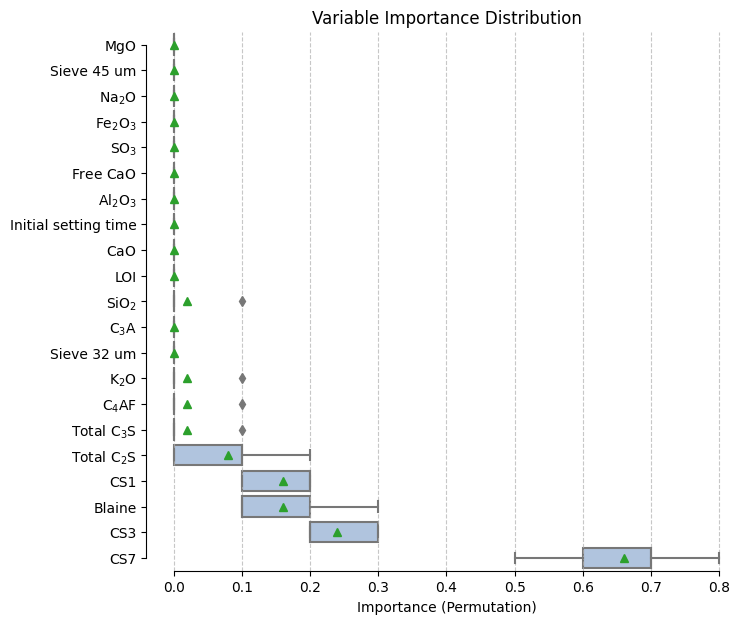

<IPython.core.display.Javascript object>

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# Backup the original backend
original_backend = plt.get_backend()

# Update font settings to default
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["DejaVu Sans"],
        "font.size": 10,
        "text.usetex": False,  # Use MathText, not LaTeX
    }
)

# Convert chemical formulas using MathText syntax
perm_importances_df_plot = perm_importances_df.rename(
    columns={
        "Alpha C2S": r"Alpha $\mathrm{C_2S}$",
        "Beta C2S": r"Beta $\mathrm{C_2S}$",
        "Gamma C2S": r"Gamma $\mathrm{C_2S}$",
        "Cubic C3A": r"Cubic $\mathrm{C_3A}$",
        "Orthorhombic C3A": r"Orthorhombic $\mathrm{C_3A}$",
        "K2O": r"$\mathrm{K_2O}$",
        "Free CaO": r"Free $\mathrm{CaO}$",
        "Total C2S": r"Total $\mathrm{C_2S}$",
        "Na2O": r"$\mathrm{Na_2O}$",
        "CaO": r"$\mathrm{CaO}$",
        "SiO2": r"$\mathrm{SiO_2}$",
        "MgO": r"$\mathrm{MgO}$",
        "Fe2O3": r"$\mathrm{Fe_2O_3}$",
        "Al2O3": r"$\mathrm{Al_2O_3}$",
        "Total C3S": r"Total $\mathrm{C_3S}$",
        "C3A": r"$\mathrm{C_3A}$",
        "C4AF": r"$\mathrm{C_4AF}$",
        "LOI": "LOI",
        "SO3": r"$\mathrm{SO_3}$",
        "Insoluble Residue": "IR",
        "Loss on Ignition": "LOI"
    }
)

plt.figure(figsize=(10, 7))

# Create boxplot
sns.boxplot(
    data=perm_importances_df_plot.round(1),
    orient="h",
    color="lightsteelblue",
    saturation=1,
    showmeans=True,
)
sns.despine(trim=True, left=False)

# Set x-axis label and title
plt.xlabel("Importance (Permutation)")
plt.title("Variable Importance Distribution")

# Add gridlines for x-axis
plt.grid(axis="x", linestyle="--", alpha=0.7)

# Format x-axis to show 1 decimal place
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:.1f}'))

# Adjust the layout to prevent label cut-off
plt.subplots_adjust(left=0.3)

# Save the plot
plt.savefig(
    "inn_cm_p_cs_tiss_linear_regression_scpm_best_dist_var_perm_relevance.png",
    dpi=300,
    bbox_inches="tight",
)

# Show the plot
plt.show()

# Reset all rcParams to their default values
plt.rcdefaults()

# Switch back to the original backend
plt.switch_backend(original_backend)


In [47]:
perm_importances_df.describe().round(4).T.sort_values(by="mean")

,count,mean,std,min,25%,50%,75%,max
MgO,5.0,-0.0008,0.0016,-0.0035,-0.0009,-0.0004,0.0002,0.0005
Sieve 45 um,5.0,0.0006,0.0024,-0.0017,-0.0003,-0.0000,0.0002,0.0046
Na2O,5.0,0.0007,0.0025,-0.0032,0.0004,0.0008,0.0020,0.0035
Fe2O3,5.0,0.0012,0.0036,-0.0022,-0.0003,-0.0002,0.0019,0.0071
SO3,5.0,0.0017,0.0027,-0.0019,0.0002,0.0017,0.0043,0.0045
Free CaO,5.0,0.0027,0.0031,0.0006,0.0010,0.0014,0.0021,0.0081
Al2O3,5.0,0.0036,0.0068,-0.0006,-0.0004,0.0017,0.0018,0.0156
Initial setting time,5.0,0.0038,0.0098,-0.0021,-0.0015,0.0002,0.0014,0.0211
CaO,5.0,0.0040,0.0064,-0.0044,0.0011,0.0027,0.0088,0.0118
LOI,5.0,0.0085,0.0141,-0.0001,0.0001,0.0034,0.0060,0.0334


<IPython.core.display.Javascript object>

In [48]:
perm_importances_df

,MgO,Sieve 45 um,Na2O,Fe2O3,SO3,Free CaO,Al2O3,Initial setting time,CaO,LOI,...,C3A,Sieve 32 um,K2O,C4AF,Total C3S,Total C2S,CS1,Blaine,CS3,CS7
0,-0.003545,-0.001695,0.000773,-0.002241,0.000152,0.001018,0.015600,0.000205,0.011819,0.000071,...,0.045887,0.045258,0.063092,0.067630,0.008713,0.061097,0.164049,0.228484,0.204417,0.533615
1,-0.000933,0.004583,-0.003218,0.007069,0.004280,0.008137,-0.000583,0.021117,-0.004425,0.033450,...,0.036802,0.010398,-0.000664,0.031983,0.001634,0.021859,0.139710,0.116484,0.224967,0.769083
2,0.000229,-0.000342,0.000361,-0.000246,0.001686,0.002051,0.001742,0.001412,0.001072,0.005963,...,0.003511,0.015718,0.017751,0.006525,0.015932,0.043229,0.191894,0.143651,0.307586,0.681532
3,0.000529,-0.000008,0.002000,-0.000274,0.004481,0.001416,-0.000410,-0.002055,0.008831,0.003363,...,0.003706,0.030655,0.015002,0.001042,0.082657,0.166797,0.193954,0.269571,0.230415,0.674736
4,-0.000367,0.000243,0.003543,0.001872,-0.001856,0.000643,0.001790,-0.001455,0.002675,-0.000113,...,0.004982,-0.003166,0.010984,-0.000472,0.048129,0.092199,0.142132,0.104214,0.275459,0.629768


<IPython.core.display.Javascript object>

In [49]:
perm_importances_df.mean(axis=0)

MgO                    -0.000817
Sieve 45 um             0.000556
Na2O                    0.000692
Fe2O3                   0.001236
SO3                     0.001748
Free CaO                0.002653
Al2O3                   0.003628
Initial setting time    0.003845
CaO                     0.003994
LOI                     0.008547
SiO2                    0.017947
C3A                     0.018977
Sieve 32 um             0.019772
K2O                     0.021233
C4AF                    0.021342
Total C3S               0.031413
Total C2S               0.077036
CS1                     0.166348
Blaine                  0.172481
CS3                     0.248569
CS7                     0.657747
dtype: float64

<IPython.core.display.Javascript object>

In [50]:
perm_importances_df.std(axis=0, ddof=0)

MgO                     0.001454
Sieve 45 um             0.002121
Na2O                    0.002247
Fe2O3                   0.003194
SO3                     0.002426
Free CaO                0.002781
Al2O3                   0.006071
Initial setting time    0.008722
CaO                     0.005759
LOI                     0.012653
SiO2                    0.034219
C3A                     0.018494
Sieve 32 um             0.016724
K2O                     0.021853
C4AF                    0.025936
Total C3S               0.030157
Total C2S               0.050455
CS1                     0.023307
Blaine                  0.065100
CS3                     0.037529
CS7                     0.076735
dtype: float64

<IPython.core.display.Javascript object>

In [51]:
# np.std(y)
len(y)
plt.rcdefaults()

# Switch back to the original backend
plt.switch_backend(original_backend)
df["CS28"].describe().T

count    1053.000000
mean       43.000541
std         3.530197
min        34.150000
25%        40.660000
50%        42.490000
75%        45.050000
max        54.560000
Name: CS28, dtype: float64

<IPython.core.display.Javascript object>